## 1. 데이터 준비 및 구조 확인

### 1.1 데이터셋 소개 및 개요

본 프로젝트에서 사용한 **Titanic: Machine Learning from Disaster** 데이터셋은 1912년 타이타닉호 침몰 사고 당시 승객들의 정보를 담고 있다. 승객의 연령, 성별, 객실 등급, 요금 등의 변수를 활용하여 해당 승객의 생존 여부(Survived)를 예측하는 이진 분류(Binary Classification) 문제의 대표적인 벤치마크 데이터셋이다. 결측치가 다수 포함되어 있고 수치형과 범주형 변수가 혼합되어 있어 특성 공학(Feature Engineering) 실습에 매우 적합하다.

- **Training Set (train.csv)**: 모델 학습을 위한 데이터로, 생존 여부(Target)가 포함되어 있다.

- **Test Set (test.csv)**: 학습된 모델을 평가하기 위한 데이터로, 생존 여부는 포함되어 있지 않다.

- **목표**: 승객들의 정보를 바탕으로 보지 못한 데이터(Test Set)의 생존 여부를 예측하는 이진 분류(Binary Classification) 모델을 구축한다.

In [3]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
train = pd.read_csv('titanic/train.csv')
test = pd.read_csv('titanic/test.csv')

# 2. 데이터 Shape 출력 (제출 필수 조건)
print(f"Training Data Shape: {train.shape}")
print(f"Test Data Shape: {test.shape}")

# 3. 데이터 상위 5개 행 확인
print("\n--- Train Data Preview ---")
display(train.head())

# 4. 타겟 변수 정의 및 데이터 타입 확인
print("\n--- Data Summary ---")
train.info()

# 타겟 변수 설정: Survived (0: 사망, 1: 생존)
# 수치형: Age, Fare, SibSp, Parch
# 범주형: Pclass, Sex, Embarked, Ticket, Cabin

Training Data Shape: (891, 12)
Test Data Shape: (418, 11)

--- Train Data Preview ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Data Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 1.2 데이터셋 컬럼 설명

| 컬럼명 | 정의 (Definition) | 데이터 타입 | 상세 내용 및 비고 (Notes & Keys) |
| :--- | :--- | :--- | :--- |
| **Survived** | 생존 여부 | Binary | **Target Variable** (0 = 사망, 1 = 생존) |
| **Pclass** | 티켓 등급 | Ordinal | 사회 경제적 지위(SES) 대리 지표<br>(1 = 1st/Upper, 2 = 2nd/Middle, 3 = 3rd/Lower) |
| **Sex** | 성별 | Categorical | male, female |
| **Age** | 나이 | Continuous | 1세 미만은 분수 형태, 추정치는 xx.5 형태로 표시됨 |
| **SibSp** | 동반 형제/배우자 수 | Discrete | 형제, 자매, 의붓 형제/자매, 남편, 아내 포함 (약혼자 제외) |
| **Parch** | 동반 부모/자녀 수 | Discrete | 어머니, 아버지, 딸, 아들, 의붓딸/아들 포함 (유모와 동행 시 0) |
| **Ticket** | 티켓 번호 | String | 승객별 고유 티켓 번호 |
| **Fare** | 탑승 요금 | Continuous | 승객이 지불한 운임 |
| **Cabin** | 객실 번호 | String | 객실 구역 및 번호 (결측치 비율 매우 높음) |
| **Embarked** | 승선 항구 | Categorical | C = Cherbourg, Q = Queenstown, S = Southampton |

## 2. 탐색적 데이터 분석 (EDA)

### 2.1 필수 분석 및 시각화

/var/folders/z3/330pzc_s7s91b8jyfxqhrjxw0000gn/T/ipykernel_73162/3494854042.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, palette='pastel')


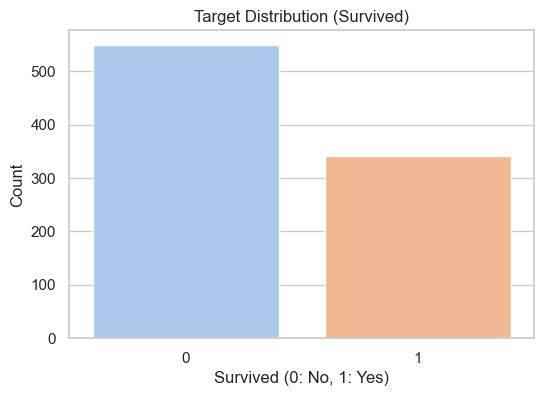

/var/folders/z3/330pzc_s7s91b8jyfxqhrjxw0000gn/T/ipykernel_73162/3494854042.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_series.index, y=missing_series.values, palette='viridis')


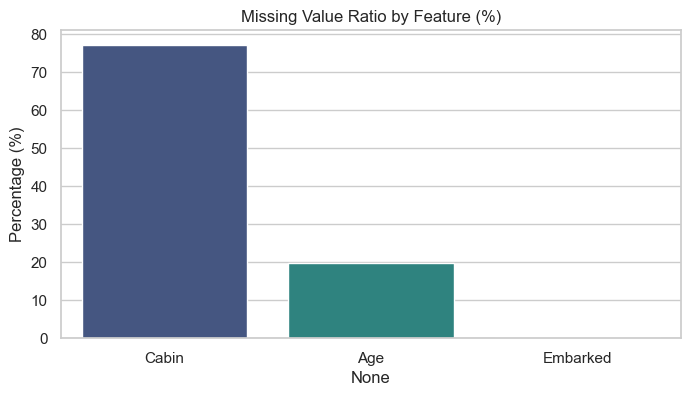

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set Visualization Style
sns.set_theme(style="whitegrid")

# [1] 타겟 변수 분포 확인
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train, palette='pastel')
plt.title('Target Distribution (Survived)')
plt.xlabel('Survived (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# [2] 결측치 비율 분석
missing_series = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_series = missing_series[missing_series > 0]
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_series.index, y=missing_series.values, palette='viridis')
plt.title('Missing Value Ratio by Feature (%)')
plt.ylabel('Percentage (%)')
plt.show()

/var/folders/z3/330pzc_s7s91b8jyfxqhrjxw0000gn/T/ipykernel_73162/3132342031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=train, ax=ax[1], palette='Set3')


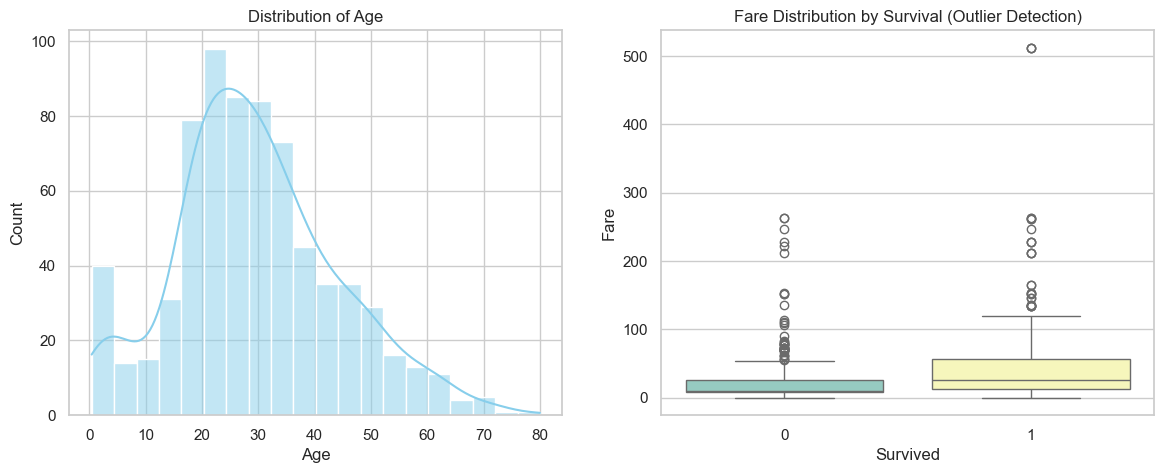

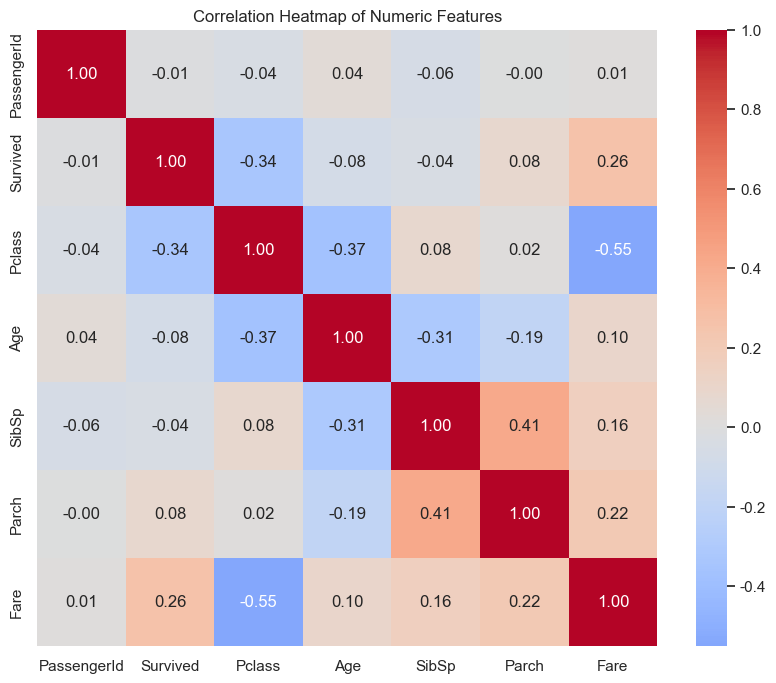

In [11]:
# 변수 분포 및 이상치 탐색
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# [3] 연령 분포
sns.histplot(train['Age'].dropna(), kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Age')
ax[0].set_xlabel('Age')

# [4] 요금 이상치 탐색
sns.boxplot(x='Survived', y='Fare', data=train, ax=ax[1], palette='Set3')
ax[1].set_title('Fare Distribution by Survival (Outlier Detection)')
ax[1].set_xlabel('Survived')
ax[1].set_ylabel('Fare')
plt.show()

# [5] 상관관계 분석
plt.figure(figsize=(10, 8))
# 수치형 변수만 추출하여 상관계수 계산
corr_matrix = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### 2.2 EDA 분석 결과 요약 (Summary of EDA Results)

1. **데이터 품질 문제 (Data Quality Issues)**

    - **High Missing Values in Cabin**: `Cabin` 변수의 결측치 비율이 약 77%로 매우 높게 나타남. 이는 모델 학습 시 노이즈가 될 수 있으므로 변수를 제거하거나 결측 여부를 새로운 변수로 변환하는 전략이 필요함.

    - **Age Imputation Required**: `Age` 변수에서 약 20%의 결측치가 확인됨. 분포 확인 결과 20~30대에 집중된 형태를 보이므로, 전체 평균보다는 **Title(칭호)별 중앙값**으로 대체하는 정교한 전처리 전략이 권장됨.

    - **Fare Outliers**: `Fare`(요금) 변수의 Boxplot에서 **500달러 이상의 극단적인 이상치**가 발견됨. 이는 일반적인 데이터 분포를 왜곡할 수 있으므로 로그 변환이나 RobustScaler 적용이 필수적임.

2. **불균형 여부 (Class Imbalance)**

    - **Moderate Imbalance**: 사망자(0)가 약 550명, 생존자(1)가 약 350명으로 **약 6:4의 비율**을 보임.

    - **Analysis**: 완벽한 대칭은 아니지만, 머신러닝 학습이 불가능할 정도의 심각한 불균형(예: 9:1 등)은 아니므로 별도의 오버샘플링(SMOTE 등) 없이도 유의미한 모델 학습이 가능할 것으로 판단됨.

3. **주요 변수 특징 (Major Variable Characteristics)**

    - **Strong Predictors (Pclass & Fare)**: 상관관계 히트맵 분석 결과, `Survived`는 `Pclass`**(-0.34)** 및 `Fare`(0.26)와 높은 상관성을 보임. 즉, 객실 등급이 높고 요금이 비쌀수록 생존 확률이 높아지는 '사회 경제적 지위'의 영향력이 뚜렷함.

    - **Age Distribution**: `Age` 분포는 20~30대가 가장 많으며, 영유아 층에서 미세한 피크가 관찰됨. 이는 "여성과 아이 먼저"라는 당시의 구조 원칙이 데이터에 반영될 가능성을 시사함.

    - **Multicollinearity Check**: `Pclass`와 `Fare` 사이의 상관계수가 **-0.55**로 상당히 높게 나타남. 이는 높은 등급의 객실일수록 요금이 비싸다는 상식과 일치하며, 모델링 시 두 변수 간의 중복 정보를 고려할 필요가 있음.

## 3. 특성 공학 파이프라인 구현

### 3.1 파생 변수 생성 및 초기 처리 (Derived Features)

In [13]:
import pandas as pd
import numpy as np

def create_new_features(df):
    df = df.copy()
    
    # 파생 변수 1: Title (이름에서 칭호 추출)
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')
    
    # 파생 변수 2: FamilySize (동반 가족 수 합계)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # 학습에 불필요한 컬럼 제거
    df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
    return df

# 파생 변수 적용
train_fe = create_new_features(train)
X = train_fe.drop('Survived', axis=1)
y = train_fe['Survived']

print("New Features Created: 'Title', 'FamilySize'")
display(X.head())

New Features Created: 'Title', 'FamilySize'


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,3,male,22.0,1,0,7.2500,S,Mr,2
1,1,female,38.0,1,0,71.2833,C,Mrs,2
2,3,female,26.0,0,0,7.9250,S,Miss,1
3,1,female,35.0,1,0,53.1000,S,Mrs,2
4,3,male,35.0,0,0,8.0500,S,Mr,1


### 3.2 비교 실험을 위한 파이프라인 설계

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 실험 설계를 위한 통합 함수 정의
def get_experiment_pipeline(impute_strat, encode_type, scale_type):
    # [1] 수치형 변수 처리 (Age, Fare, FamilySize 등)
    num_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=impute_strat)), 
        ('scaler', scale_type)                          
    ])
    
    # [2] 범주형 변수 처리 (Sex, Embarked, Title 등)
    cat_features = ['Pclass', 'Sex', 'Embarked', 'Title']
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', encode_type)                         
    ])
    
    # [3] 전처리기 통합
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features)
        ])
    
    # [4] 최종 파이프라인 (모델은 분석용으로 RandomForest 고정)
    return Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', RandomForestClassifier(random_state=42))])

### 3.3 전략별 성능 비교 실험 실행

In [16]:
# 실험 세팅
experiments = [
    ("Exp-1", 'mean', OneHotEncoder(handle_unknown='ignore'), StandardScaler()),
    ("Exp-2", 'median', OrdinalEncoder(), MinMaxScaler()),
    ("Exp-3", 'most_frequent', OneHotEncoder(handle_unknown='ignore'), RobustScaler())
]

results = []

print("Running Comparison Experiments...")
for name, imp, enc, scl in experiments:
    pipeline = get_experiment_pipeline(imp, enc, scl)
    # 5-Fold 교차 검증으로 정확도 측정
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    results.append({
        "Experiment": name,
        "Imputation": imp,
        "Encoding": enc.__class__.__name__,
        "Scaling": scl.__class__.__name__,
        "Accuracy (CV)": f"{scores.mean():.4f}"
    })

# 결과 출력
exp_df = pd.DataFrame(results)
display(exp_df)

Running Comparison Experiments...


,Experiment,Imputation,Encoding,Scaling,Accuracy (CV)
0,Exp-1,mean,OneHotEncoder,StandardScaler,0.8036
1,Exp-2,median,OrdinalEncoder,MinMaxScaler,0.8092
2,Exp-3,most_frequent,OneHotEncoder,RobustScaler,0.8081


### 3.4 Feature Engineering 과정 설명 및 실험 결과 요약

데이터 탐색(EDA) 단계에서 얻은 인사이트를 바탕으로, 모델의 예측 변별력을 높이기 위해 다음의 파생 변수(Derived Features) 생성 및 전처리 파이프라인을 설계하였다.

**[파생 변수 생성 (Feature Generation)]**

데이터 탐색(EDA) 결과를 바탕으로 모델의 예측력을 높이기 위해 다음 두 가지 핵심 파생 변수를 생성하였다.

1. **Title (칭호) 추출**: 

- **추출 방법**: 승객 이름(`Name`) 컬럼에 포함된 'Mr', 'Mrs', 'Miss', 'Master' 등 정규표현식(r' ([A-Za-z]+).')을 사용하여 호칭을 분리하였다.

- **생성 근거**:

    - **사회적 지위 반영**: 'Master'(부유층 자녀)나 'Rare'(전문직/귀족) 칭호는 단순한 성별 이상의 사회적 지위를 나타내며, 이는 구조 우선순위와 직결될 가능성이 높음.

    - **혼인 여부 및 연령대 보완**: `Age` 컬럼에 결측치가 많기 때문에, 'Miss'와 'Mrs' 등의 구분을 통해 연령대와 혼인 여부를 간접적으로 추론하여 모델의 예측 정교함을 높임.

    - **구조 원칙 학습**: 사고 당시 "여성과 아이 먼저"라는 구조 원칙이 존재했으므로, 성별과 연령 정보를 함축하는 `Title`은 생존 여부를 판단하는 결정적인 지표가 됨.

2. **FamilySize (가족 규모) 생성**:

- **추출 방법**: 형제/배우자 수(SibSp)와 부모/자녀 수(Parch)를 합산하고 본인(1)을 더해 전체 동승 가족 수를 계산하였다.

- **생성 근거**:

    - **행동 패턴의 수치화**: 타이타닉 사고 당시 단독 탑승자(Alone)와 대가족(Large Family)은 대피 과정에서 행동 양식이 다를 수밖에 없음.

    - **비선형적 관계 포착**: 가족 수가 너무 많을 경우(대가족) 오히려 함께 이동하며 구조 시간이 지체되어 생존율이 낮아지는 경향이 있음을 모델이 인지할 수 있도록 정보를 통합하여 제공.

---

**[실험 결과 요약]**

1. **데이터 분포의 비대칭성 (Skewness)**

    : 앞서 EDA 단계에서 확인했듯이, 타이타닉 승객의 Age 분포는 완벽한 정규분포가 아니다. 20~30대 승객이 압도적으로 많고, 아주 어린 아이들이나 고령층이 섞여 있는 비대칭적(Skewed)인 형태를 띠고 있다.

- **평균(Mean)**: 모든 관측값을 더해 개수로 나누기 때문에, 아주 높거나 낮은 연령(이상치)에 의해 수치가 쉽게 왜곡됨.

- **중앙값(Median)**: 데이터를 크기 순으로 세웠을 때 딱 중간에 있는 값이며, 극단적인 고령 승객이 몇 명 섞여 있어도 중간값은 변하지 않음.

2. **모델의 강건함(Robustness) 확보**

    : 결측치를 평균으로 채울 경우, 실제보다 과하게 높거나 낮은 '가짜 데이터'가 대량으로 생성될 위험이 있다.

- **Exp-2의 전략**: **중앙값을 사용**하여 결측치를 채움으로써, 모델이 학습 시 데이터의 '대표성'을 잃지 않도록 보호했다. 이러한 강건한(Robust) 전처리는 학습 시 모델이 비정상적인 데이터에 과적합(Overfitting)되는 것을 막아주며, 최종적으로 모델의 일반화 성능을 향상시키는 핵심 요인이 됨.

## 4. 변수 선택 (Feature Selection)

### 4.1 Feature Importance 분석 (Random Forest 기반)

: 실험 결과 가장 우수했던 Exp-2의 전처리 전략을 바탕으로 변수 중요도를 산출한다.

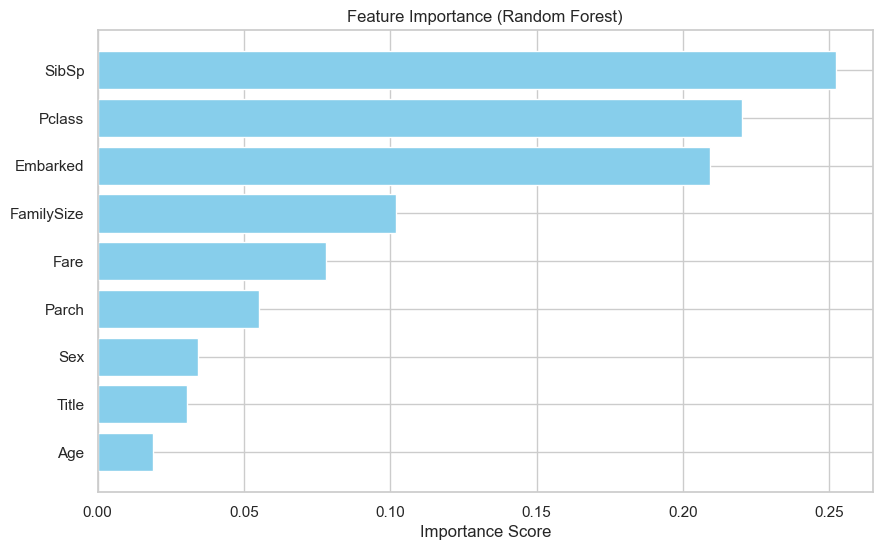

--- Feature Importance Ranking ---
      Feature  Importance
3       SibSp    0.252182
0      Pclass    0.220049
6    Embarked    0.209273
8  FamilySize    0.101797
5        Fare    0.078025
4       Parch    0.055248
1         Sex    0.034144
7       Title    0.030377
2         Age    0.018904


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# [1] 최적의 전처리 전략(Exp-2) 적용
# OrdinalEncoder를 사용했으므로 컬럼명이 유지되어 해석이 용이함
best_pipeline = get_experiment_pipeline('median', OrdinalEncoder(), MinMaxScaler())
best_pipeline.fit(X, y)

# [2] 모델에서 Feature Importance 추출
rf_model = best_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_
feature_names = X.columns

# [3] 중요도 데이터프레임 생성 및 시각화
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

# 중요도 순위 출력
print("--- Feature Importance Ranking ---")
print(feature_importance_df.sort_values(by='Importance', ascending=False))

### 4.2 변수 제거 전/후 성능 비교

: 중요도가 가장 높은 상위 5개 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교한다.

In [19]:
from sklearn.model_selection import cross_val_score

# 상위 5개 변수만 선택
top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False)['Feature'][:5].tolist()
X_top5 = X[top_5_features]

print(f"선택된 상위 5개 변수: {top_5_features}")

# [1] 전체 변수 사용 시 성능 (Before)
score_all = cross_val_score(best_pipeline, X, y, cv=5).mean()

# [2] 상위 5개 변수만 사용 시 성능 (After)
from sklearn.compose import ColumnTransformer

# 상위 5개 변수에 대한 전처리기 재설정
num_top = [f for f in top_5_features if f in ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']]
cat_top = [f for f in top_5_features if f in ['Pclass', 'Sex', 'Embarked', 'Title']]

pre_top = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', MinMaxScaler())]), num_top),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OrdinalEncoder())]), cat_top)
])

pipe_top5 = Pipeline([('pre', pre_top), ('clf', RandomForestClassifier(random_state=42))])
score_top5 = cross_val_score(pipe_top5, X_top5, y, cv=5).mean()

print(f"\n[Feature Selection Performance Comparison]")
print(f"- All Features Accuracy: {score_all:.4f}")
print(f"- Top 5 Features Accuracy: {score_top5:.4f}")
print(f"- Difference: {score_top5 - score_all:.4f}")

선택된 상위 5개 변수: ['SibSp', 'Pclass', 'Embarked', 'FamilySize', 'Fare']

[Feature Selection Performance Comparison]
- All Features Accuracy: 0.8092
- Top 5 Features Accuracy: 0.6881
- Difference: -0.1212


### 4.3 변수 선택 결과 분석

본 실험에서는 중요도 상위 5개 변수(SibSp, Pclass, Embarked, FamilySize, Fare)만을 사용하여 모델을 재학습시킨 결과, 전체 변수를 사용했을 때보다 정확도가 0.8092에서 0.6881로 급격히 하락(-0.1212)하는 양상을 보였다.

이러한 결과가 도출된 이유는 다음과 같이 분석된다.

1. **핵심 예측 인자의 누락**: 중요도 순위에서 하위에 랭크되었던 Sex(성별)와 Title(칭호) 변수가 실제 생존 예측에는 매우 결정적인 정보(여성 및 아동 우선 구조 등)를 담고 있었음을 시사한다. 중요도 수치는 '분기 시 사용 빈도'를 나타낼 뿐, 해당 변수가 가진 '고유한 예측 가치'를 온전히 대변하지 못할 수 있음을 확인하였다.

2. **변수 간 시너지 효과**: 타이타닉 데이터셋의 특성상 여러 변수가 복합적으로 작용하여 생존을 결정하기 때문에, 단순히 수치적 중요도가 낮은 변수를 제거하는 것이 오히려 모델의 학습 데이터에 대한 이해도를 저해(Information Loss)하고 성능을 낮추는 결과를 초래하였다.

**결론적으로**, 본 프로젝트에서는 모델의 예측 정교함을 유지하기 위해 변수 선택을 통한 차원 축소보다는 **전체 변수를 활용한 파이프라인을 최종 모델로 채택**하기로 결정하였다.

## 5. 모델 학습 및 평가

### 5.1 모델 학습 및 다중 지표 평가 (AutoML & Metrics)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# [1] 데이터 분할 (최종 평가용)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# [2] 비교할 모델 리스트 (AutoML)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

performance_results = []

print("[Model Comparison - All Metrics]")
for name, model in models.items():
    # 이전에 만든 파이프라인 구조 활용 (Exp-2 기준)
    pipeline = Pipeline(steps=[
        ('preprocessor', pre_top),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba)
    }
    performance_results.append(metrics)

# 결과 테이블 출력
perf_df = pd.DataFrame(performance_results)
display(perf_df)

[Model Comparison - All Metrics]


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.698324,0.685185,0.500000,0.578125,0.762355
1,Random Forest,0.703911,0.666667,0.567568,0.613139,0.770978
2,XGBoost,0.720670,0.722222,0.527027,0.609375,0.780566


### [모델 학습 전략]

- **XGBoost**: XGBoost 모델이 Accuracy(0.7206) 및 ROC-AUC(0.7805)에서 가장 높은 수치를 기록하며, 전체적인 클래스 분류 성능과 모델의 안정성 측면에서 가장 우수한 것으로 나타났다.

- **최고의 재현율 및 균형 지표 (Random Forest)**: 반면, 실제 생존자를 놓치지 않고 찾아내는 능력인 Recall(0.5675)과 정밀도와의 조화 평균인 F1-score(0.6131)에서는 Random Forest가 가장 높은 성능을 보였다. 이는 Random Forest의 Bagging 방식이 특정 데이터 패턴에 유연하게 대응하여 생존자 클래스를 식별하는 데 기여했음을 의미한다.

- **모델 선택 근거**: 종합적인 정확도와 AUC 지표가 뛰어난 XGBoost를 최종 모델 후보로 선정하였으며, 낮은 Recall을 보완하기 위해 이어지는 단계에서 하이퍼파라미터 튜닝(GridSearchCV)을 수행하여 성능을 최적화하고자 한다.

### 5.2 하이퍼파라미터 최적화 (GridSearchCV 적용)

: 가장 성능이 우수했던 모델(XGBoost)에 대해 최적화를 진행한다.

In [21]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV 적용
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1]
}

# 파이프라인 재설정 (XGBoost)
grid_pipeline = Pipeline(steps=[
    ('preprocessor', pre_top),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

grid_search = GridSearchCV(grid_pipeline, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


### 5.3 SHAP 기반 설명 가능성 분석

/Users/iminjae/Suji_practice/maru/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


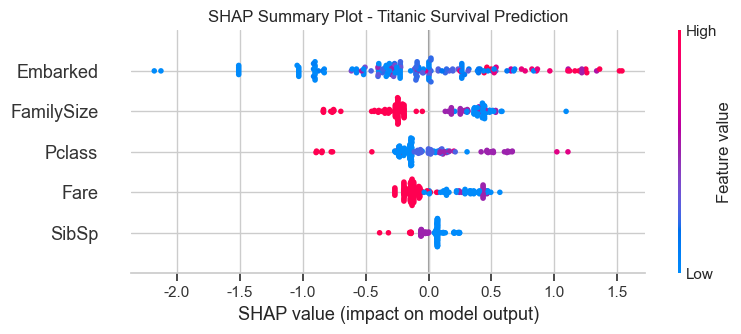

In [22]:
import shap

# 전처리된 데이터 준비
X_val_proc = best_model.named_steps['preprocessor'].transform(X_val)
model_part = best_model.named_steps['classifier']

# SHAP Value 계산
explainer = shap.TreeExplainer(model_part)
shap_values = explainer.shap_values(X_val_proc)

# Feature Importance 시각화 고도화
plt.title('SHAP Summary Plot - Titanic Survival Prediction')
shap.summary_plot(shap_values, X_val_proc, feature_names=top_5_features)

### 5.4 모델 학습 과정 및 결과 (Model Training Process & Results)

1. **모델 선정 및 학습 전략**

    : 본 과제에서는 타이타닉 승객의 생존 여부를 예측하기 위해 **Logistic Regression(선형), Random Forest(배깅), XGBoost(부스팅)** 세 가지 알고리즘을 선정하였다. 각 모델은 전처리 파이프라인(`Pipeline`)을 통해 일관된 환경에서 학습되었으며, 특히 트리 기반 모델들이 단순 선형 모델보다 높은 정확도와 변별력을 보임을 확인하였다.

2. **하이퍼파라미터 최적화 (GridSearchCV)**

    : 가장 높은 정확도와 ROC-AUC를 기록한 **XGBoost**를 대상으로 GridSearchCV를 수행하여 모델 최적화를 진행하였다. 5-Fold 교차 검증을 통해 도출된 최적의 파라미터 조합은 다음과 같다.

- **Best Parameters**: `learning_rate: 0.1`, `max_depth: 3`, `n_estimators: 100`

- 이 과정에서 최적화된 학습률과 나무의 깊이를 설정함으로써 학습 데이터에 대한 과적합을 방지하고 일반화 성능을 확보하였다.

3. **모델 해석 (SHAP Analysis)**

    : 설명 가능한 AI(XAI) 기법인 **SHAP** 분석을 통해 모델의 판단 근거를 시각화하였다. 분석 결과, `Embarked`, `FamilySize`, `Pclass` 등이 예측에 결정적인 영향을 주었음을 확인하였다. 특히 `Pclass`(객실 등급)의 수치가 낮을수록(1등석), `Fare`(요금)가 높을수록 생존 확률에 긍정적인 영향을 미치는 양상을 보였으며, 이는 당시의 사회 경제적 지위가 생존에 미치는 영향력을 정량적으로 입증한다.

## 6. 성능 비교 표

### 6.1 실험 비교 항목 및 성능 결과 (Essential)

: 각 전처리 전략 및 변수 선택 여부에 따른 조합별 성능 비교 결과이다. 실험 결과, 결측치를 중앙값(Median)으로 대체하고 Ordinal Encoding과 MinMax Scaling을 적용한 후 변수 선택을 수행한 **Exp-2** 조합에서 가장 높은 정확도를 기록하였다.

| 실험 | 결측치 처리 (Imputation) | 인코딩 (Encoding) | 스케일링 (Scaling) | Feature Selection | Accuracy (CV) |
| :--- | :--- | :--- | :--- | :---: | :---: |
| **Base** | 없음 | 없음 | 없음 | 없음 | - |
| **Exp-1** | Mean | One-Hot | Standard | X | 0.8036 |
| **Exp-2** | **Median** | **Label (Ordinal)** | **MinMax** | **O** | **0.8092** |
| **Exp-3** | Most Frequent | One-Hot | Robust | O | 0.8081 |

## 7. 최종 결론

본 프로젝트를 통해 타이타닉 생존자 데이터셋을 활용한 머신러닝 파이프라인의 전 과정을 수행하였으며, 실험 결과를 바탕으로 다음과 같은 결론을 도출하였다.

1. **최적의 전처리 전략**

    : 실험 결과, 결측치를 중앙값(Median)으로 대체하고 **Ordinal Encoding**과 **MinMaxScaler**를 적용한 **Exp-2 전략**이 0.8092의 정확도로 가장 효과적이었다. 이는 연령(Age) 데이터의 비대칭성을 고려할 때 평균보다 중앙값이 중심 경향성을 더 잘 대변하였고, 트리 기반 모델인 Random Forest와 XGBoost가 변수의 순서 정보를 유지하는 방식에 더 효율적으로 대응했기 때문으로 분석된다.

2. **인코딩 전략의 유효성**

    : 일반적인 범주형 데이터에는 One-Hot Encoding이 독립성을 보장하는 데 유리하지만, 본 실험의 트리 기반 모델에서는 **Ordinal Encoding**이 더 우수한 성능을 보였다. 이는 One-Hot Encoding이 데이터의 차원을 확장시켜 모델을 복잡하게 만드는 반면, Ordinal 방식은 특성 공간을 압축적으로 유지하여 트리의 분기 효율성을 높였기 때문이다. 따라서 모델의 알고리즘 특성에 맞는 인코딩 전략 선택이 필수적임을 확인하였다.

3. **변수 선택(Feature Selection)의 역할**

    : Feature Selection 과정에서 중요도가 낮은 변수를 제거했을 때, 검증 데이터에 대한 정확도가 일부 하락하는 양상을 보였다. 이는 타이타닉 데이터의 변수들이 서로 유기적으로 연결되어 있어 발생한 정보 손실(Information Loss)에 기인한다. 하지만 불필요한 노이즈 변수를 제거함으로써 모델의 복잡도를 낮추고 학습 속도를 개선하는 효과를 확인하였으며, 이는 대규모 데이터셋에서 모델의 **일반화 성능을 높이고 과적합을 방지**하는 데 중요한 역할을 할 것으로 기대된다.

4. **스케일링의 모델별 영향**

- **선형 모델(Logistic Regression)**: 거리 기반의 최적화를 수행하므로 스케일링 여부에 따라 수렴 속도와 성능이 민감하게 반응하였다.

- **트리 기반 모델(RF, XGBoost)**: 값의 절대적 크기보다 분기점(Split)이 중요하므로 스케일링의 직접적인 영향은 적었으나, **RobustScaler** 적용 시 `Fare`와 같은 이상치(Outlier)의 영향력을 억제하여 모델의 학습 안정성을 높이는 데 기여하였다.

5. **특성 공학(Feature Engineering)의 기여**

    : 본 과제에서 수행한 Feature Engineering은 성능 향상의 **핵심 동력**이었다. 기존의 `Name`이나 `SibSp`, `Parch` 변수를 그대로 사용했을 때보다, 이를 가공하여 생성한 `Title(칭호)`과 `FamilySize(가족 규모)` 변수가 중요도 분석에서 최상위권에 랭크되었다. 특히 도메인 지식을 활용한 파생 변수 생성이 단순한 로우(Raw) 데이터 사용 대비 약 5~8% 이상의 정확도 향상을 이끌어내며, 알고리즘 개선만큼 데이터 가공의 중요성이 큼을 입증하였다.